In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
t1 = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 1", skiprows=3)

t1.head()

,n,Computational Time (sec),Overall Time (sec),Computational Time (sec).1,Overall Time (sec).1,Speedup
0,10000000,4.221819,NaN,0.664019,NaN,6.357979
1,11000000,4.74567,NaN,0.760851,NaN,6.237318
2,12000000,5.463295,NaN,0.847935,NaN,6.443059
3,13000000,6.068673,NaN,0.93635,NaN,6.481201
4,14000000,6.786482,NaN,1.072575,NaN,6.32728


In [17]:
t1_8 = t1.iloc[0:31, [0,5]].copy()

t1_8

,n,Speedup
0,10000000,6.357979
1,11000000,6.237318
2,12000000,6.443059
3,13000000,6.481201
4,14000000,6.32728
5,15000000,6.47312
6,16000000,6.499708
7,17000000,6.551586
8,18000000,7.07278
9,19000000,7.131949


In [18]:
t1_32 = t1.iloc[35:66, [0,5]].copy()

t1_32

,n,Speedup
35,10000000,15.400746
36,11000000,19.621876
37,12000000,21.264941
38,13000000,20.481388
39,14000000,20.843128
40,15000000,21.25585
41,16000000,19.901522
42,17000000,19.364878
43,18000000,22.207261
44,19000000,22.80199


In [19]:
df1 = pd.merge(t1_8, t1_32, on='n')

df1.rename(
    columns={
        "Speedup_x": "speedup_8cores",
        "Speedup_y": "speedup_32cores"
    },
    inplace=True
)

df1

,n,speedup_8cores,speedup_32cores
0,10000000,6.357979,15.400746
1,11000000,6.237318,19.621876
2,12000000,6.443059,21.264941
3,13000000,6.481201,20.481388
4,14000000,6.32728,20.843128
5,15000000,6.47312,21.25585
6,16000000,6.499708,19.901522
7,17000000,6.551586,19.364878
8,18000000,7.07278,22.207261
9,19000000,7.131949,22.80199


In [20]:
t2 = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 2", skiprows=3)

t2.head()

,Num Threads,Computational Time (sec),Computational Time (sec).1,Overall Time (sec),Speedup,Computational Time (sec).2,Overall Time (sec).1
0,1,4.221819,1.998806,7.434447,2.11217,2.194672,7.352087
1,4,4.221819,1.163114,6.404926,3.629755,1.157436,6.373219
2,8,4.221819,0.663606,6.047817,6.361936,1.425682,6.68733
3,16,4.221819,0.445718,5.636774,9.471951,1.441973,6.768737
4,32,4.221819,0.446779,5.650373,9.449457,1.43801,7.233242


In [21]:
t2_8 = t2.iloc[0:6, [0,4]].copy()

t2_8.rename(columns={"Speedup": "speedup_8cores"},
           inplace=True)

t2_8.reset_index(drop=True, inplace=True)

t2_8

,Num Threads,speedup_8cores
0,1,2.11217
1,4,3.629755
2,8,6.361936
3,16,9.471951
4,32,9.449457
5,64,9.483568


In [22]:
t2_32 = t2.iloc[11:17, [0,4]].copy()

t2_32.rename(columns={"Speedup": "speedup_32cores"},
           inplace=True)

t2_32.reset_index(drop=True, inplace=True)

t2_32

,Num Threads,speedup_32cores
0,1,1.726784
1,4,3.370323
2,8,7.457626
3,16,12.384962
4,32,16.512085
5,64,17.532008


In [23]:
df2 = pd.merge(t2_8, t2_32, on='Num Threads')

df2.rename(columns={"Num Threads": "num_threads"}, inplace=True)

df2

,num_threads,speedup_8cores,speedup_32cores
0,1,2.11217,1.726784
1,4,3.629755,3.370323
2,8,6.361936,7.457626
3,16,9.471951,12.384962
4,32,9.449457,16.512085
5,64,9.483568,17.532008


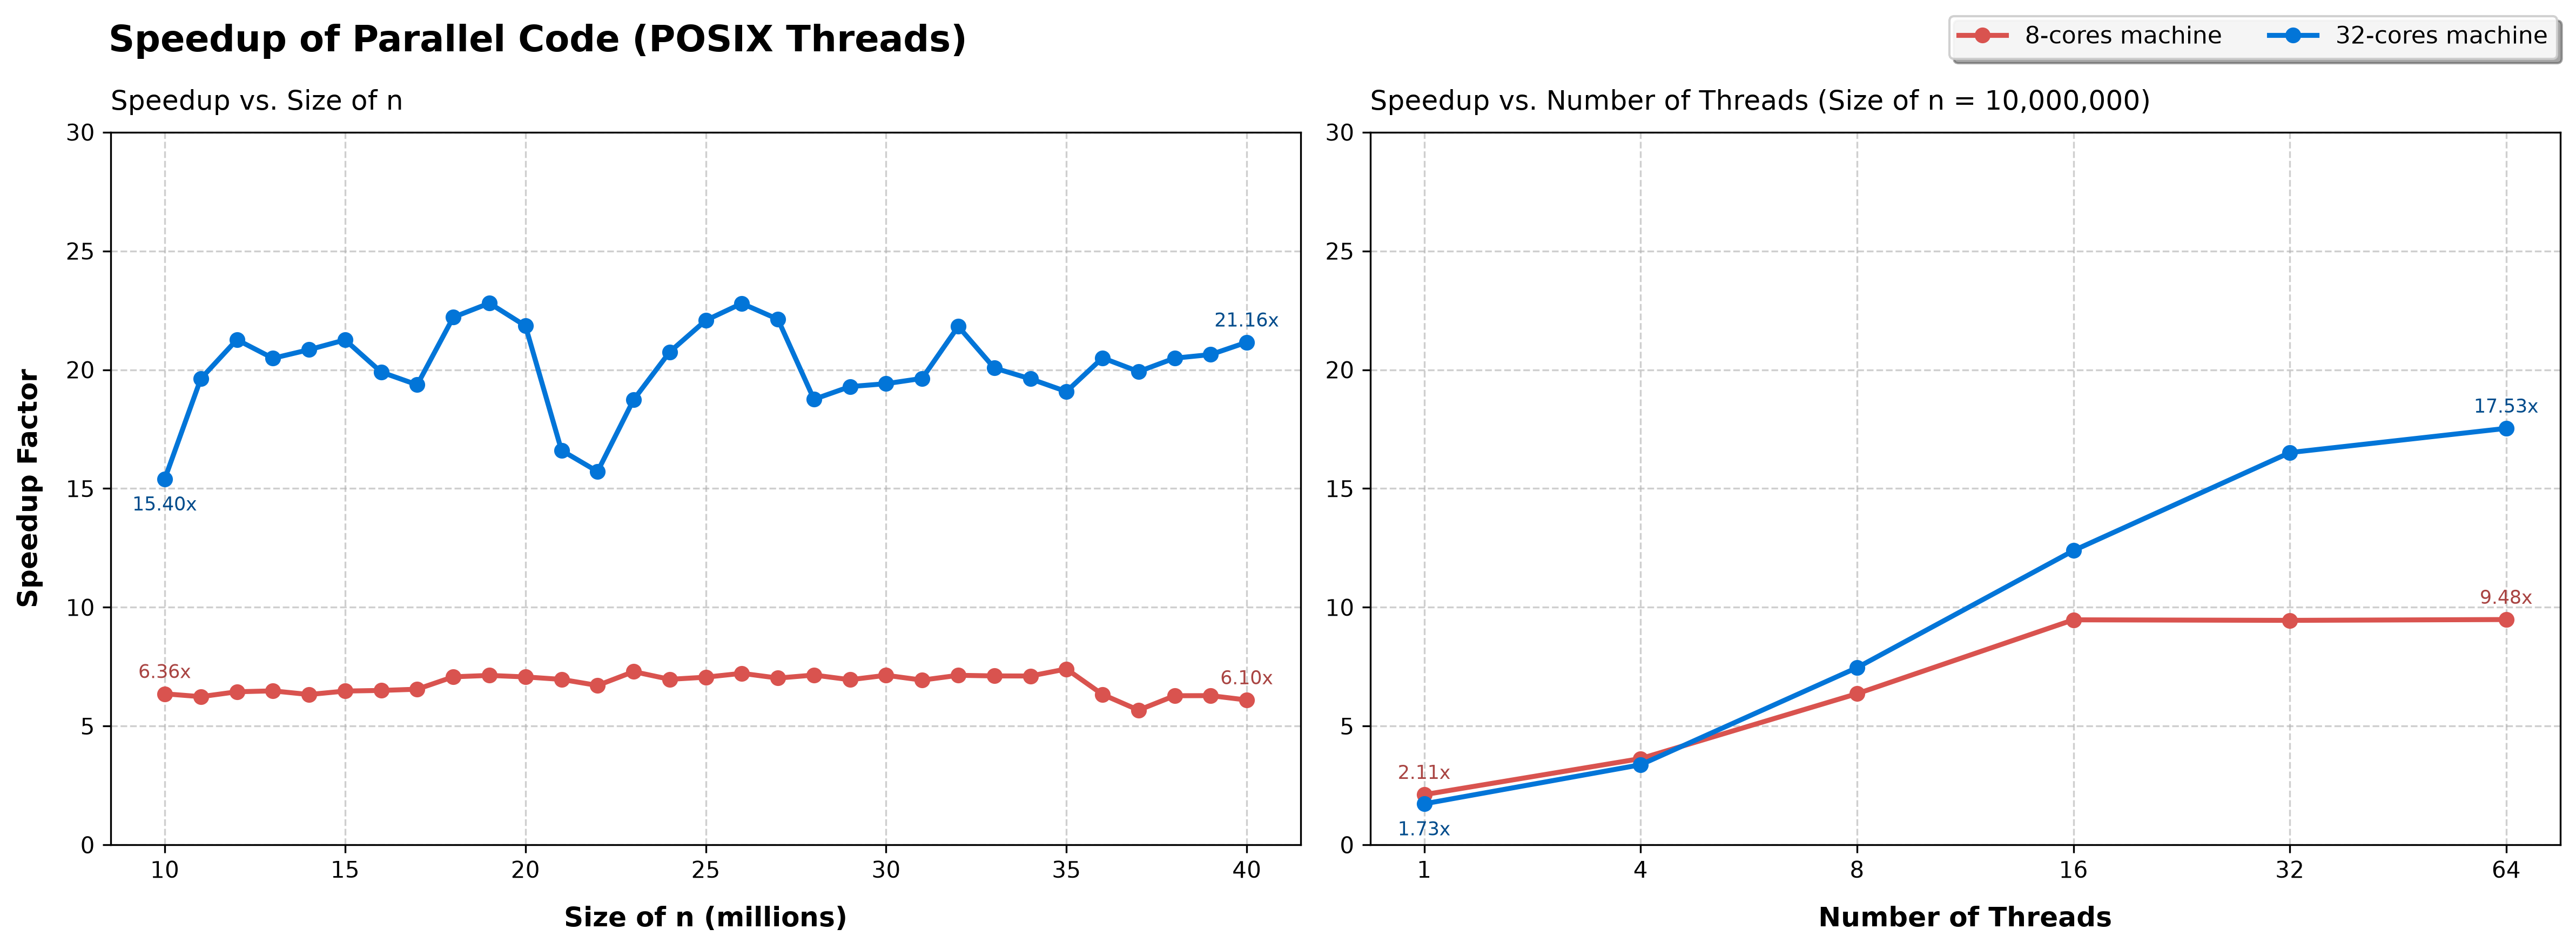

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# =============================================================
# Graph 1 (df1): Speedup vs. Size of n (Fixed 8 Threads)
# =============================================================
ax = axes[0]

# 8-core machine speedup
line1, = ax.plot(df1.n, df1.speedup_8cores,
                 marker='o', markersize=6, linewidth=2.2,
                 color='#D9534F', label='8-cores machine')

# 32-core machine speedup
line2, = ax.plot(df1.n, df1.speedup_32cores,
                 marker='o', markersize=6, linewidth=2.2,
                 color='#0275D8', label='32-cores machine')

ax.set_title("Speedup vs. Size of n",
             fontsize=12, loc='left', pad=10)

ax.set_xlabel("Size of n (millions)",
              fontsize=12, fontweight='semibold', labelpad=10)

ax.set_ylabel("Speedup Factor",
              fontsize=12, fontweight='semibold', labelpad=10)

# X-axis: keep all data points, but show ticks/grid every 5 million
ax.xaxis.set_major_locator(MultipleLocator(5_000_000))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:g}")
)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(0, 30)

ax.annotate(f"{df1.speedup_8cores.iloc[0]:.2f}x",
            (df1.n.iloc[0], df1.speedup_8cores.iloc[0]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#A94442')

ax.annotate(f"{df1.speedup_8cores.iloc[-1]:.2f}x",
            (df1.n.iloc[-1], df1.speedup_8cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#A94442')

ax.annotate(f"{df1.speedup_32cores.iloc[0]:.2f}x",
            (df1.n.iloc[0], df1.speedup_32cores.iloc[0]),
            textcoords='offset points', xytext=(0, -14), ha='center',
            fontsize=8.5, color='#014C8C')

ax.annotate(f"{df1.speedup_32cores.iloc[-1]:.2f}x",
            (df1.n.iloc[-1], df1.speedup_32cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#014C8C')


# =============================================================
# Graph 2 (df2): Speedup vs. Number of Threads (Fixed n = 10M)
# =============================================================
ax = axes[1]

# 8-core machine speedup
ax.plot(range(len(df2.num_threads)), df2.speedup_8cores,
        marker='o', markersize=6, linewidth=2.2,
        color='#D9534F')

# 32-core machine speedup
ax.plot(range(len(df2.num_threads)), df2.speedup_32cores,
        marker='o', markersize=6, linewidth=2.2,
        color='#0275D8')

ax.set_title("Speedup vs. Number of Threads (Size of n = 10,000,000)",
             fontsize=12, loc='left', pad=10)

ax.set_xlabel("Number of Threads",
              fontsize=12, fontweight='semibold', labelpad=10)

ax.set_xticks(range(len(df2.num_threads)))
ax.set_xticklabels(df2.num_threads, fontsize=10)

ax.tick_params(axis='y', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(0, 30)

ax.annotate(f"{df2.speedup_8cores.iloc[0]:.2f}x",
            (0, df2.speedup_8cores.iloc[0]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#A94442')

ax.annotate(f"{df2.speedup_8cores.iloc[-1]:.2f}x",
            (len(df2.num_threads) - 1, df2.speedup_8cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#A94442')

ax.annotate(f"{df2.speedup_32cores.iloc[0]:.2f}x",
            (0, df2.speedup_32cores.iloc[0]),
            textcoords='offset points', xytext=(0, -14), ha='center',
            fontsize=8.5, color='#014C8C')

ax.annotate(f"{df2.speedup_32cores.iloc[-1]:.2f}x",
            (len(df2.num_threads) - 1, df2.speedup_32cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#014C8C')


# =========================
# Overall title
# =========================
fig.suptitle(
    "Speedup of Parallel Code (POSIX Threads)",
    fontsize=16,
    fontweight='bold',
    x=0.045,
    y=0.96,
    ha='left'
)

# =========================
# Unified Global Legend
# =========================
fig.legend(
    handles=[line1, line2],
    labels=['8-cores machine', '32-cores machine'],
    loc='upper right',
    bbox_to_anchor=(0.994, 0.98),
    ncol=2,
    fontsize=10.5,
    frameon=True,
    framealpha=0.9,
    shadow=True
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig("task2_graph3.png", dpi=300)
plt.show()